# Notebook 8 - Restauración de imágenes (Inpainting)

https://scikit-image.org/docs/stable/api/skimage.restoration.html

## Objetivo

Aplicar la técnica de restauración de imágenes (*inpainting*) para reconstruir regiones dañadas de una imagen.

## Descripción

En algunas aplicaciones de visión artificial es necesario recuperar información faltante o deteriorada en una imagen.

La técnica de **inpainting** utiliza la información disponible alrededor de las regiones dañadas para estimar los valores faltantes y reconstruir la imagen.

En este ejercicio se utilizará la función:

```python
restoration.inpaint_biharmonic()
```

para restaurar una fotografía que contiene regiones dañadas artificialmente.

---

## Paso 1. Importar las librerías necesarias

```python
from skimage import restoration
import matplotlib.pyplot as plt
import numpy as np
```

---

## Paso 2. Cargar la imagen dañada

La imagen utilizada en este ejercicio se encuentra almacenada en:

```text
../Images/damaged_astronaut.png
```

```python
imagen_danada = plt.imread('../Images/damaged_astronaut.png')
```

---

## Paso 3. Crear la máscara de las regiones dañadas

La máscara es una imagen binaria que indica las regiones que deben reconstruirse.

En este caso, las zonas dañadas corresponden a píxeles completamente negros.

```python
mask = np.all(imagen_danada == 0, axis=-1)
```

---

## Paso 4. Aplicar el algoritmo de restauración

La función `inpaint_biharmonic()` utiliza la información de los píxeles vecinos para reconstruir las regiones dañadas.

```python
imagen_restaurada = restoration.inpaint_biharmonic(
    imagen_danada,
    mask,
    channel_axis=-1
)
```

---

## Paso 5. Visualizar los resultados

```python
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(imagen_danada)
ax[0].set_title('Imagen dañada')
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Máscara')
ax[1].axis('off')

ax[2].imshow(imagen_restaurada)
ax[2].set_title('Imagen restaurada')
ax[2].axis('off')

plt.tight_layout()
plt.show()
```

---

## Preguntas de análisis

1. ¿Qué regiones de la imagen fueron reconstruidas?
2. ¿La reconstrucción fue igualmente efectiva en todas las zonas dañadas?
3. ¿Qué función cumple la máscara dentro del proceso de restauración?
4. ¿Por qué la información de los píxeles vecinos es importante para el algoritmo?
5. ¿En qué aplicaciones reales podría utilizarse la restauración de imágenes?
6. ¿Qué limitaciones observas en el resultado obtenido?

---

## Actividad adicional

Modifica manualmente la imagen agregando nuevas regiones dañadas y analiza el comportamiento del algoritmo.

¿La calidad de la restauración cambia cuando aumenta el tamaño de la región faltante?

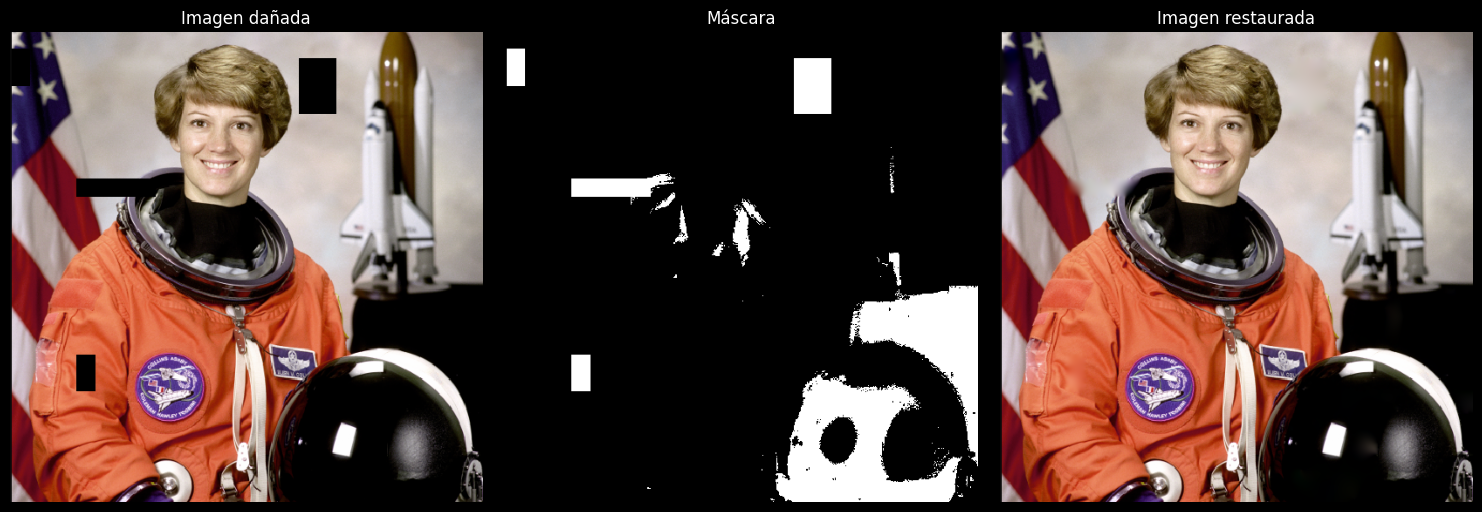

In [3]:

from skimage import restoration
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Cargar imagen dañada
# =====================================================

imagen_danada = plt.imread('../Images/damaged_astronaut.png')

# =====================================================
# Crear máscara de regiones dañadas
# Los cuadros dañados son negros
# =====================================================

mask = np.all(imagen_danada == 0, axis=-1)

# =====================================================
# Restaurar imagen
# =====================================================

imagen_restaurada = restoration.inpaint_biharmonic(
    imagen_danada,
    mask,
    channel_axis=-1
)

# =====================================================
# Mostrar resultados
# =====================================================

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(imagen_danada)
ax[0].set_title('Imagen dañada')
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Máscara')
ax[1].axis('off')

ax[2].imshow(imagen_restaurada)
ax[2].set_title('Imagen restaurada')
ax[2].axis('off')

plt.tight_layout()
plt.show()


En este ejercicio se eliminará un logotipo presente en una imagen mediante la función:

```python
restoration.inpaint_biharmonic()
```

---

## Paso 1. Importar las librerías necesarias

```python
from skimage import io
from skimage import restoration
import matplotlib.pyplot as plt
import numpy as np
```

---

## Paso 2. Cargar la imagen

La imagen utilizada en este ejercicio se encuentra almacenada en:

```text
../Images/image_with_logo.png
```

```python
imagen_logo = plt.imread('../Images/image_with_logo.png')
```

---

## Paso 3. Visualizar la imagen original

```python
plt.figure(figsize=(8,5))

plt.imshow(imagen_logo)
plt.title('Imagen original')
plt.axis('off')

plt.show()
```

---

## Paso 4. Crear una máscara

La máscara debe tener el mismo tamaño que la imagen.

Inicialmente todos los valores serán cero.

```python
mask = np.zeros(imagen_logo.shape[:-1])
```

---

## Paso 5. Seleccionar la región que contiene el logotipo

Los píxeles correspondientes al logotipo se establecen en uno.

```python
mask[210:290, 360:425] = 1
```

---

## Paso 6. Visualizar la máscara

```python
plt.figure(figsize=(6,6))

plt.imshow(mask, cmap='gray')
plt.title('Máscara')
plt.axis('off')

plt.show()
```

---

## Paso 7. Aplicar Inpainting

La máscara indica al algoritmo qué región debe reconstruirse.

```python
imagen_sin_logo = restoration.inpaint_biharmonic(
    imagen_logo,
    mask,
    channel_axis=-1
)
```

---

## Paso 8. Mostrar la imagen restaurada

```python
plt.figure(figsize=(8,5))

plt.imshow(imagen_sin_logo)
plt.title('Imagen sin logotipo')
plt.axis('off')

plt.show()
```

---

## Paso 9. Comparar resultados

```python
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(imagen_logo)
ax[0].set_title('Imagen original')
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Máscara')

ax[2].imshow(imagen_sin_logo)
ax[2].set_title('Imagen restaurada')
ax[2].axis('off')

plt.tight_layout()
plt.show()
```

---

## Preguntas de análisis

1. ¿Qué función cumple la máscara dentro del proceso de restauración?
2. ¿Por qué es necesario indicar la región a reconstruir?
3. ¿El logotipo desapareció completamente?
4. ¿Qué información utiliza el algoritmo para rellenar la región eliminada?
5. ¿Qué ocurriría si la región a eliminar fuera mucho más grande?
6. ¿En qué aplicaciones reales podría utilizarse esta técnica?

---

## Actividad adicional

Modifica las coordenadas de la máscara para eliminar otros objetos de la imagen.

Prueba diferentes tamaños de máscara y analiza cómo cambia la calidad de la reconstrucción.

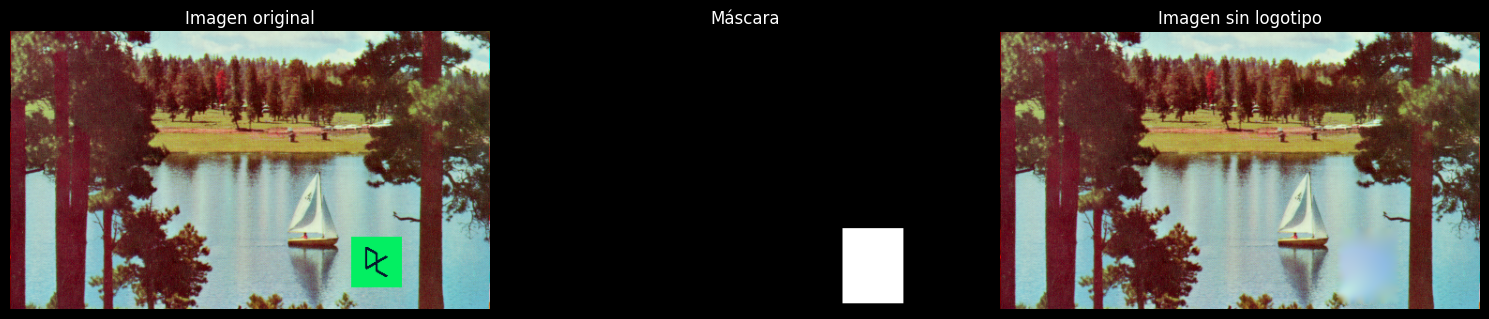

In [4]:
from skimage import restoration
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Cargar imagen con logotipo
# =====================================================

imagen_logo = plt.imread('../Images/image_with_logo.png')

# =====================================================
# Crear máscara con el mismo alto y ancho de la imagen
# =====================================================

mask = np.zeros(imagen_logo.shape[:-1])

# =====================================================
# Seleccionar la región donde está el logotipo
# =====================================================

mask[210:290, 360:425] = 1

# =====================================================
# Aplicar inpainting para eliminar el logotipo
# =====================================================

imagen_sin_logo = restoration.inpaint_biharmonic(
    imagen_logo,
    mask,
    channel_axis=-1
)

# =====================================================
# Mostrar resultados
# =====================================================

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(imagen_logo)
ax[0].set_title('Imagen original')
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Máscara')
ax[1].axis('off')

ax[2].imshow(imagen_sin_logo)
ax[2].set_title('Imagen sin logotipo')
ax[2].axis('off')

plt.tight_layout()
plt.show()